# Multi-day Pipeline V3

Same shape as `multi_day_pipeline.ipynb`, but the exit/return classification
is replaced with the **v3 spike-healed symmetric** logic from
`components.v3_pipeline_restructure.ipynb`.

For each `(date, system)` folder under `data/flight_data/`:

1. Load `flight_tracks.csv` + `detections.csv`.
2. Per-track: nullify frames with frame-to-frame speed > 7 m/s, linearly
   interpolate the gaps, centered rolling-mean (window 5) to smooth, drop
   tracks shorter than 10 valid frames.
3. Run **v3 exit** detection: speed (min < 0.5 m/s in head) + start position
   within 0.3 m of hive + backward extrapolation hits the 0.15 m hive sphere
   (auto-pass if already inside) + outward cosine ≥ 0.3 (skipped at hover speed).
4. Run **v3 return** detection (symmetric on the tail).
5. Also compute the legacy `hive_*_v1` columns so v1↔v3 can be diffed.
6. Compute per-track tortuosity (after smoothing).

Then aggregate exactly like the legacy multi-day pipeline:
- Greedy pairing of v3 exits → next un-matched v3 return per (date, system).
- Daily counts, return ratio, trip duration, median tortuosity, IFI-CV.
- Joins: `flower_visit_summary.csv`, `Power levels (dBm)*.csv`,
  `Data transfer*.csv`.
- Cycle / condition labels (BASELINE / ON / OFF, anchor = 2026-04-23).
- Sign-aligned indicators → `indicators_daily.csv`.

Writes everything under `data/multi_day_v3/` so it doesn't overwrite the legacy
multi_day outputs.


In [40]:
from pathlib import Path
from datetime import datetime
import re
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

# --- Date / system filter -------------------------------------------------
DATES      = pd.date_range("2026-04-13", "2026-05-28")              # None = all dates; or pd.date_range("2026-04-19","2026-05-09")
SYSTEM_IDS = [900, 939]

# --- Hive positions per camera -------------------------------------------
HIVE_BY_SYSTEM = {
    900: np.array([-0.04,  -0.665, -1.195], dtype=float),
    939: np.array([-0.086, -0.828, -1.045], dtype=float),
}

# --- Classifier windows & legacy v1 tolerance ----------------------------
TOL          = 0.10   # m — legacy v1 sphere radius (used ONLY for v1 booleans)
HEAD_FRAMES  = 10     # v3 inspects the first 10 frames for take-off
TAIL_FRAMES  = 10     # v3 inspects the last 10 frames for landing
FPS          = 60.0   # PATS-C frame rate

# --- v3 thresholds (mirror components.v3_pipeline_restructure.ipynb) -----
HIVE_SPHERE_V3            = 0.15    # m — extrapolation target sphere
SPEED_THRESHOLD_TAKEOFF   = 0.5
SPEED_THRESHOLD_LANDING   = 0.5
START_NEAR_HIVE_MAX       = 0.10    # m — exit:   first position ≤ this  (was 0.20)
END_NEAR_HIVE_MAX         = 0.10    # m — return: last position ≤ this  (was 0.30)
APPROACH_COS_MIN_EXIT     = 0.30
APPROACH_COS_MIN_RETURN   = 0.30

# --- v3 leniency knobs ---------------------------------------------------
USE_MIN_SPEED_FOR_THRESHOLD     = True   # use min speed in window, not mean
AUTO_PASS_EXTRAPOLATION_AT_HIVE = True   # already-at-hive auto-passes extrapolation
HOVER_SPEED_MIN                 = 0.10   # below this, skip cosine check
APPROACH_DIR_FRAME_OFFSET       = 10     # frames outside head/tail for direction

# --- Spike healing & smoothing -------------------------------------------
MAX_BIO_VELOCITY = 7.0
SMOOTH_WINDOW    = 5
MIN_TRACK_FRAMES = 10

# --- Cycle labels --------------------------------------------------------
CYCLE_ANCHOR = pd.Timestamp("2026-04-23")

# --- Paths ---------------------------------------------------------------
DATA_BASE = Path("../../../data/flight_data")
DATA_ROOT = Path("../../../data")          # parent of flight_data/ — used for dBm/xfer
OUT_DIR   = Path("data/multi_day_v3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source: {DATA_BASE.resolve()}")
print(f"Output: {OUT_DIR.resolve()}")


Source: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/data/flight_data
Output: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/data/multi_day_v3


In [41]:
# ---------------------------------------------------------------------------
# Helpers — spike healing, v3 classifiers, v1 classifiers, tortuosity
# ---------------------------------------------------------------------------

POS_COLS = ["posX_insect", "posY_insect", "posZ_insect"]


def heal_and_smooth_track(trk: pd.DataFrame) -> pd.DataFrame | None:
    """Per-track: heal velocity spikes, interpolate gaps, smooth with a
    centered rolling mean.  Returns None if < MIN_TRACK_FRAMES valid frames
    survive after cleaning.  Adds `is_interpolated` and `spike_flagged` cols."""
    trk = trk.copy().reset_index(drop=True)

    if "pos_valid_insect" in trk.columns:
        valid_mask = trk["pos_valid_insect"] == 1
    else:
        valid_mask = pd.Series(True, index=trk.index)

    coords = trk[POS_COLS].astype(float).copy()
    coords.loc[~valid_mask] = np.nan

    dt = 1.0 / FPS
    speed = np.linalg.norm(coords.diff().values, axis=1) / dt
    spike_mask = pd.Series(speed > MAX_BIO_VELOCITY, index=coords.index).fillna(False)
    coords.loc[spike_mask.values] = np.nan

    interpolated_mask = spike_mask.values | (~valid_mask.values)
    coords = coords.interpolate(method="linear", limit_direction="both")

    if coords.dropna().shape[0] < MIN_TRACK_FRAMES:
        return None

    smoothed = (coords
                .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
                .mean())

    out = trk.copy()
    out[POS_COLS] = smoothed.values
    out["is_interpolated"] = interpolated_mask
    out["spike_flagged"]   = spike_mask.values
    return out


def line_passes_within_radius(point, direction, target, radius, require_forward=True):
    d_norm = np.linalg.norm(direction)
    if d_norm < 1e-9:
        return False, np.nan, float("inf")
    direction = direction / d_norm
    to_target = target - point
    t = float(np.dot(to_target, direction))
    closest_point = point + t * direction
    closest_dist  = float(np.linalg.norm(closest_point - target))
    if require_forward and t < 0:
        return False, t, closest_dist
    return (closest_dist <= radius), t, closest_dist


def _valid_coords_arr(trk):
    arr = trk[POS_COLS].to_numpy(dtype=float)
    mask = ~np.isnan(arr).any(axis=1)
    return arr[mask]


def classify_exit_v3(trk, hive):
    coords = _valid_coords_arr(trk)
    if len(coords) < HEAD_FRAMES:
        return None

    head = coords[:HEAD_FRAMES]
    dt = 1.0 / FPS

    head_velocities = np.diff(head, axis=0) / dt
    head_speeds     = np.linalg.norm(head_velocities, axis=1)
    initial_speed_mean = float(np.mean(head_speeds))
    initial_speed_min  = float(np.min(head_speeds))
    speed_for_threshold = (initial_speed_min if USE_MIN_SPEED_FOR_THRESHOLD
                           else initial_speed_mean)
    is_taking_off = speed_for_threshold < SPEED_THRESHOLD_TAKEOFF

    dir_end = min(HEAD_FRAMES + APPROACH_DIR_FRAME_OFFSET, len(coords))
    if APPROACH_DIR_FRAME_OFFSET > 0 and (dir_end - HEAD_FRAMES) >= 2:
        dir_velocities = np.diff(coords[HEAD_FRAMES:dir_end], axis=0) / dt
    else:
        dir_velocities = head_velocities
    mean_velocity = dir_velocities.mean(axis=0)
    speed_norm    = float(np.linalg.norm(mean_velocity))
    velocity_unit = mean_velocity / speed_norm if speed_norm >= 1e-9 else np.zeros(3)

    hits_sphere, t_close, dist_close = line_passes_within_radius(
        point=head[0], direction=-velocity_unit, target=hive,
        radius=HIVE_SPHERE_V3, require_forward=True,
    )
    start_dist_to_hive = float(np.linalg.norm(head[0] - hive))
    start_near_hive    = start_dist_to_hive <= START_NEAR_HIVE_MAX
    auto_passed = AUTO_PASS_EXTRAPOLATION_AT_HIVE and start_dist_to_hive <= HIVE_SPHERE_V3
    hits_sphere_eff = hits_sphere or auto_passed

    outward = head[0] - hive
    outward_norm = np.linalg.norm(outward)
    if outward_norm < 1e-9 or speed_norm < 1e-9:
        cos_outward = 0.0
    else:
        cos_outward = float(np.dot(velocity_unit, outward) / outward_norm)
    cos_check = (speed_norm < HOVER_SPEED_MIN) or (cos_outward >= APPROACH_COS_MIN_EXIT)

    return {
        "initial_speed_min": initial_speed_min,
        "start_dist":        start_dist_to_hive,
        "outward_cos":       cos_outward,
        "hive_exit_v3": bool(is_taking_off and hits_sphere_eff and start_near_hive and cos_check),
    }


def classify_return_v3(trk, hive):
    coords = _valid_coords_arr(trk)
    if len(coords) < TAIL_FRAMES:
        return None

    tail = coords[-TAIL_FRAMES:]
    dt = 1.0 / FPS

    tail_velocities = np.diff(tail, axis=0) / dt
    tail_speeds     = np.linalg.norm(tail_velocities, axis=1)
    terminal_speed_mean = float(np.mean(tail_speeds))
    terminal_speed_min  = float(np.min(tail_speeds))
    speed_for_threshold = (terminal_speed_min if USE_MIN_SPEED_FOR_THRESHOLD
                           else terminal_speed_mean)
    is_landing = speed_for_threshold < SPEED_THRESHOLD_LANDING

    n = len(coords)
    dir_start = max(n - TAIL_FRAMES - APPROACH_DIR_FRAME_OFFSET, 0)
    dir_end   = n - TAIL_FRAMES
    if APPROACH_DIR_FRAME_OFFSET > 0 and (dir_end - dir_start) >= 2:
        dir_velocities = np.diff(coords[dir_start:dir_end], axis=0) / dt
    else:
        dir_velocities = tail_velocities
    mean_velocity = dir_velocities.mean(axis=0)
    speed_norm    = float(np.linalg.norm(mean_velocity))
    velocity_unit = mean_velocity / speed_norm if speed_norm >= 1e-9 else np.zeros(3)

    hits_sphere, t_close, dist_close = line_passes_within_radius(
        point=tail[-1], direction=velocity_unit, target=hive,
        radius=HIVE_SPHERE_V3, require_forward=True,
    )
    end_dist_to_hive = float(np.linalg.norm(tail[-1] - hive))
    end_near_hive    = end_dist_to_hive <= END_NEAR_HIVE_MAX
    auto_passed = AUTO_PASS_EXTRAPOLATION_AT_HIVE and end_dist_to_hive <= HIVE_SPHERE_V3
    hits_sphere_eff = hits_sphere or auto_passed

    toward = hive - tail[-1]
    toward_norm = np.linalg.norm(toward)
    if toward_norm < 1e-9 or speed_norm < 1e-9:
        cos_toward = 0.0
    else:
        cos_toward = float(np.dot(velocity_unit, toward) / toward_norm)
    cos_check = (speed_norm < HOVER_SPEED_MIN) or (cos_toward >= APPROACH_COS_MIN_RETURN)

    return {
        "terminal_speed_min": terminal_speed_min,
        "end_dist":           end_dist_to_hive,
        "toward_cos":         cos_toward,
        "hive_return_v3": bool(is_landing and hits_sphere_eff and end_near_hive and cos_check),
    }


def classify_exit_v1(coords, hive):
    head = coords[:HEAD_FRAMES]
    if len(head) == 0:
        return False, np.nan
    d = float(np.min(np.linalg.norm(head - hive, axis=1)))
    return (d <= TOL), d


def classify_return_v1(coords, hive):
    tail = coords[-TAIL_FRAMES:]
    if len(tail) == 0:
        return False, np.nan
    d = float(np.min(np.linalg.norm(tail - hive, axis=1)))
    return (d <= TOL), d


def path_tortuosity(xyz):
    """Arc length / end-to-end displacement. >= 1.0; 1.0 means perfect line."""
    if xyz is None or len(xyz) < 2:
        return np.nan
    arc = float(np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum())
    end_to_end = float(np.linalg.norm(xyz[-1] - xyz[0]))
    return np.nan if end_to_end < 1e-6 else arc / end_to_end


In [42]:
# ---------------------------------------------------------------------------
# Iterate (date, system) folders → heal → classify → accumulate
# ---------------------------------------------------------------------------

folder_pat = re.compile(r"^(\d{4}-\d{2}-\d{2})_system_(\d+)$")

if DATES is None:
    target_dates = None
else:
    target_dates = set(pd.to_datetime(DATES).strftime("%Y-%m-%d"))

day_sys_folders = sorted(p for p in DATA_BASE.iterdir() if p.is_dir())

per_track_rows  = []
daily_rows      = []

for d in day_sys_folders:
    m = folder_pat.match(d.name)
    if not m:
        continue
    date_str, sys_str = m.groups()
    sys_id = int(sys_str)
    if sys_id not in SYSTEM_IDS:
        continue
    if target_dates is not None and date_str not in target_dates:
        continue
    if sys_id not in HIVE_BY_SYSTEM:
        print(f"  skipping {d.name} — no hive position for system {sys_id}")
        continue

    det_csv = d / "detections.csv"
    ft_csv  = d / "flight_tracks.csv"
    if not det_csv.exists() or not ft_csv.exists():
        print(f"  skipping {d.name} — missing detections.csv or flight_tracks.csv")
        continue

    dets = pd.read_csv(det_csv)
    dets["ts"] = pd.to_datetime(dets["datetime"], format="%Y%m%d_%H%M%S", errors="coerce")

    ft_cols_wanted = ["detection_uid", "pos_valid_insect",
                      "posX_insect", "posY_insect", "posZ_insect", "elapsed"]
    ft = pd.read_csv(ft_csv, usecols=lambda c: c in ft_cols_wanted)
    ft_by_uid = dict(tuple(ft.groupby("detection_uid")))

    hive = HIVE_BY_SYSTEM[sys_id]

    n_tracks = 0
    n_dropped = 0
    n_spike_tracks = 0
    n_v1_exit = n_v3_exit = 0
    n_v1_ret  = n_v3_ret  = 0
    exit_ts   = []
    return_ts = []

    for _, det in dets.iterrows():
        uid = int(det["uid"])
        trk = ft_by_uid.get(uid)
        if trk is None or len(trk) == 0:
            continue
        if "elapsed" in trk.columns:
            trk = trk.sort_values("elapsed")

        cleaned = heal_and_smooth_track(trk)
        if cleaned is None:
            n_dropped += 1
            continue
        n_tracks += 1
        if cleaned["spike_flagged"].any():
            n_spike_tracks += 1

        coords = _valid_coords_arr(cleaned)
        if len(coords) < HEAD_FRAMES:
            continue

        is_v1_exit, _ = classify_exit_v1(coords, hive)
        is_v1_ret,  _ = classify_return_v1(coords, hive)
        ex_v3 = classify_exit_v3(cleaned, hive)
        rt_v3 = classify_return_v3(cleaned, hive)
        if ex_v3 is None or rt_v3 is None:
            continue

        is_v3_exit = ex_v3["hive_exit_v3"]
        is_v3_ret  = rt_v3["hive_return_v3"]

        if is_v1_exit: n_v1_exit += 1
        if is_v3_exit:
            n_v3_exit += 1
            exit_ts.append(det["ts"])
        if is_v1_ret:  n_v1_ret += 1
        if is_v3_ret:
            n_v3_ret += 1
            return_ts.append(det["ts"])

        per_track_rows.append({
            "date":           date_str,
            "system_id":      sys_id,
            "uid":            uid,
            "ts":             det["ts"],
            "n_samples":      int(len(cleaned)),
            "n_spike_frames": int(cleaned["spike_flagged"].sum()),
            "hive_exit_v1":   bool(is_v1_exit),
            "hive_return_v1": bool(is_v1_ret),
            "hive_exit_v3":   bool(is_v3_exit),
            "hive_return_v3": bool(is_v3_ret),
            "initial_speed_min":  ex_v3["initial_speed_min"],
            "start_dist":         ex_v3["start_dist"],
            "outward_cos":        ex_v3["outward_cos"],
            "terminal_speed_min": rt_v3["terminal_speed_min"],
            "end_dist":           rt_v3["end_dist"],
            "toward_cos":         rt_v3["toward_cos"],
            "tortuosity":         path_tortuosity(coords),
        })

    # --- Greedy trip pairing (v3 exits → next un-matched v3 return) ----
    ex_sorted = sorted(t for t in exit_ts   if pd.notna(t))
    rt_sorted = sorted(t for t in return_ts if pd.notna(t))
    used  = [False] * len(rt_sorted)
    trips = []
    for et in ex_sorted:
        for j, rt in enumerate(rt_sorted):
            if used[j] or rt <= et:
                continue
            trips.append((rt - et).total_seconds())
            used[j] = True
            break
    median_trip = float(np.median(trips)) if trips else np.nan
    mean_trip   = float(np.mean(trips))   if trips else np.nan
    n_matched   = len(trips)

    daily_rows.append({
        "date":          date_str,
        "system_id":     sys_id,
        "n_tracks":      n_tracks,
        "n_dropped":     n_dropped,
        "n_spike_tracks": n_spike_tracks,
        "n_exit_v1":     n_v1_exit,
        "n_exit_v3":     n_v3_exit,
        "n_return_v1":   n_v1_ret,
        "n_return_v3":   n_v3_ret,
        "re_ratio_v3":   (n_v3_ret / n_v3_exit) if n_v3_exit > 0 else np.nan,
        "median_trip_s": median_trip,
        "mean_trip_s":   mean_trip,
        "n_matched":     n_matched,
    })

    print(f"  {d.name}: tracks={n_tracks}  v3_ex={n_v3_exit}  v3_ret={n_v3_ret}  trips={n_matched}")

per_track     = pd.DataFrame(per_track_rows)
daily_summary = pd.DataFrame(daily_rows)
print(f"\nDays processed: {len(daily_summary)}.  Total tracks: {len(per_track):,}")


  2026-04-13_system_900: tracks=369  v3_ex=13  v3_ret=22  trips=11
  2026-04-14_system_900: tracks=1246  v3_ex=102  v3_ret=86  trips=86
  2026-04-15_system_900: tracks=1518  v3_ex=130  v3_ret=130  trips=129
  2026-04-16_system_900: tracks=935  v3_ex=67  v3_ret=76  trips=67
  2026-04-17_system_900: tracks=1302  v3_ex=119  v3_ret=142  trips=119
  2026-04-18_system_900: tracks=2401  v3_ex=260  v3_ret=270  trips=260
  2026-04-19_system_900: tracks=1080  v3_ex=86  v3_ret=133  trips=86
  2026-04-20_system_900: tracks=1283  v3_ex=124  v3_ret=148  trips=123
  2026-04-21_system_900: tracks=859  v3_ex=55  v3_ret=66  trips=55
  2026-04-21_system_939: tracks=603  v3_ex=6  v3_ret=5  trips=4
  2026-04-22_system_900: tracks=846  v3_ex=69  v3_ret=64  trips=64
  2026-04-22_system_939: tracks=659  v3_ex=45  v3_ret=38  trips=38
  2026-04-23_system_900: tracks=793  v3_ex=63  v3_ret=68  trips=62
  2026-04-23_system_939: tracks=643  v3_ex=47  v3_ret=32  trips=28
  2026-04-24_system_900: tracks=898  v3_ex=62

KeyboardInterrupt: 

In [29]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [30]:
# ---------------------------------------------------------------------------
# Persist per-track + daily summary (these are inputs to everything below)
# ---------------------------------------------------------------------------

per_track.to_csv(OUT_DIR / "per_track_indicators.csv", index=False)
daily_summary.to_csv(OUT_DIR / "daily_summary.csv", index=False)
print(f"Wrote per_track_indicators.csv  ({len(per_track):,} rows)")
print(f"Wrote daily_summary.csv         ({len(daily_summary):,} rows)")


Wrote per_track_indicators.csv  (237 rows)
Wrote daily_summary.csv         (1 rows)


In [31]:
# ---------------------------------------------------------------------------
# Daily indicators: median tortuosity + IFI-CV → base `indicators` frame
# ---------------------------------------------------------------------------

tort = (per_track.groupby(["date", "system_id"])["tortuosity"]
                  .median()
                  .reset_index(name="path_tortuosity"))


def _ifi_cv(group):
    ts = group.loc[group["hive_exit_v3"], "ts"].sort_values()
    if len(ts) < 3:
        return np.nan
    iv = pd.to_datetime(ts).diff().dropna().dt.total_seconds()
    if iv.mean() == 0:
        return np.nan
    return float(iv.std() / iv.mean())


ifi = (per_track.groupby(["date", "system_id"])
                 .apply(_ifi_cv, include_groups=False)
                 .reset_index(name="ifi_cv"))

indicators = (daily_summary
              .merge(tort, on=["date", "system_id"], how="left")
              .merge(ifi,  on=["date", "system_id"], how="left"))

print(f"Base indicators frame: {indicators.shape}")
print(indicators[["date","system_id","n_exit_v3","n_return_v3","re_ratio_v3",
                  "path_tortuosity","ifi_cv"]].head().to_string(index=False))


Base indicators frame: (1, 15)
      date  system_id  n_exit_v3  n_return_v3  re_ratio_v3  path_tortuosity   ifi_cv
2026-06-02        900         12           15         1.25          2.77243 1.368917


In [32]:
# ---------------------------------------------------------------------------
# Flower-visit join (optional — produced by flower_visit_pipeline.ipynb)
# ---------------------------------------------------------------------------

fv_path = OUT_DIR / "flower_visit_summary.csv"
legacy_fv_path = Path("data/multi_day/flower_visit_summary.csv")

# Prefer a v3-local one if present, otherwise fall back to the legacy file.
fv_use = fv_path if fv_path.exists() else (legacy_fv_path if legacy_fv_path.exists() else None)

if fv_use is not None:
    fv = pd.read_csv(fv_use)
    fv["date"] = pd.to_datetime(fv["date"]).dt.strftime("%Y-%m-%d")
    indicators["date"] = pd.to_datetime(indicators["date"]).dt.strftime("%Y-%m-%d")
    fv_cols = [c for c in ["date", "system_id", "mean_handling_time_s",
                            "n_distinct_flowers", "median_handling_time_s",
                            "n_visits", "revisit_rate"]
               if c in fv.columns]
    indicators = indicators.merge(fv[fv_cols], on=["date", "system_id"], how="left")
    print(f"Joined flower_visit_summary from {fv_use}  ({len(fv)} rows). "
          f"Indicators: {indicators.shape}")
else:
    print(f"!!! flower_visit_summary.csv not found.  Run flower_visit_pipeline.ipynb.")
    indicators["mean_handling_time_s"] = np.nan
    indicators["n_distinct_flowers"]   = np.nan


Joined flower_visit_summary from data/multi_day/flower_visit_summary.csv  (82 rows). Indicators: (1, 20)


In [33]:
# ---------------------------------------------------------------------------
# dBm signal strength + data-transfer join
# ---------------------------------------------------------------------------

SENSOR_TO_SYSTEM = {6: 900, 4: 939}   # PROVISIONAL — confirm

dbm_candidates  = sorted(DATA_ROOT.glob("Power levels (dBm)*.csv"))
xfer_candidates = sorted(DATA_ROOT.glob("Data transfer*.csv"))
print(f"dBm files found:           {[p.name for p in dbm_candidates]}")
print(f"data-transfer files found: {[p.name for p in xfer_candidates]}")

if dbm_candidates:
    dbm = pd.read_csv(dbm_candidates[-1])
    dbm["timestamp"] = pd.to_datetime(dbm["timestamp"])
    dbm["date"]      = dbm["timestamp"].dt.strftime("%Y-%m-%d")
    dbm["system_id"] = dbm["sensor"].map(SENSOR_TO_SYSTEM)

    dbm_daily = (dbm.dropna(subset=["system_id"])
                    .groupby(["date", "system_id"])
                    .agg(mean_dbm=("dBm","mean"),
                         max_dbm =("dBm","max"),
                         median_dbm=("dBm","median"))
                    .reset_index())
    dbm_daily["system_id"] = dbm_daily["system_id"].astype(int)
    indicators = indicators.merge(dbm_daily, on=["date","system_id"], how="left")
    print(f"Joined dBm: {dbm_daily.shape}")
else:
    indicators["mean_dbm"]   = np.nan
    indicators["max_dbm"]    = np.nan
    indicators["median_dbm"] = np.nan
    print("(no dBm file — columns left as NaN)")

if xfer_candidates:
    xfer = pd.read_csv(xfer_candidates[-1])
    xfer["timestamp"] = pd.to_datetime(xfer["timestamp"])
    xfer["date"]      = xfer["timestamp"].dt.strftime("%Y-%m-%d")
    xfer["mbps"] = (xfer["data"].astype(str).str.extract(r"([\d.]+)")[0].astype(float))
    xfer_daily = (xfer.groupby("date")
                      .agg(mean_mbps=("mbps","mean"),
                           max_mbps =("mbps","max"))
                      .reset_index())
    indicators = indicators.merge(xfer_daily, on=["date"], how="left")
    print(f"Joined data-transfer: {xfer_daily.shape}")
else:
    indicators["mean_mbps"] = np.nan
    indicators["max_mbps"]  = np.nan
    print("(no data-transfer file — columns left as NaN)")

print(f"\nWith dBm + transfer: {indicators.shape}")


dBm files found:           ['Power levels (dBm)-data-2026-05-26.csv']
data-transfer files found: ['Data transfer-data-2026-05-26.csv']
Joined dBm: (1, 5)
Joined data-transfer: (1, 3)

With dBm + transfer: (1, 25)


In [34]:
# ---------------------------------------------------------------------------
# Cycle / condition labels (anchor = CYCLE_ANCHOR, 3-day ON/OFF blocks)
# ---------------------------------------------------------------------------

def label_date(d):
    d = pd.Timestamp(d)
    if d < CYCLE_ANCHOR:
        return "BASELINE"
    return "ON" if ((d - CYCLE_ANCHOR).days // 3) % 2 == 0 else "OFF"


indicators["date_ts"]   = pd.to_datetime(indicators["date"])
indicators["condition"] = indicators["date_ts"].apply(label_date)
indicators["cycle"]     = ((indicators["date_ts"] - CYCLE_ANCHOR).dt.days // 6).clip(lower=-1)

print(indicators[["date","system_id","condition","cycle"]].head(8).to_string(index=False))


      date  system_id condition  cycle
2026-06-02        900       OFF      6


In [35]:
# ---------------------------------------------------------------------------
# Sign-aligned indicators → indicators_daily.csv  (positive = impairment direction)
# ---------------------------------------------------------------------------

indicators["neg_exit_count"] = -indicators["n_exit_v3"].astype(float)
indicators["neg_re_ratio"]   = -indicators["re_ratio_v3"]

INDICATORS = [
    "neg_exit_count",
    "neg_re_ratio",
    "path_tortuosity",
    "ifi_cv",
    "mean_handling_time_s",
    "n_distinct_flowers",
]

out_cols = (["date", "system_id", "condition", "cycle"]
            + INDICATORS
            + ["n_exit_v3", "n_return_v3", "re_ratio_v3", "median_trip_s", "mean_trip_s",
               "n_matched", "n_visits", "mean_dbm", "max_dbm", "median_dbm",
               "mean_mbps", "max_mbps"])
out_cols = [c for c in out_cols if c in indicators.columns]
indicators_daily = (indicators[out_cols]
                    .sort_values(["system_id", "date"])
                    .reset_index(drop=True))

OUT_PATH = OUT_DIR / "indicators_daily.csv"
indicators_daily.to_csv(OUT_PATH, index=False)
print(f"Wrote {OUT_PATH}  ({len(indicators_daily)} rows, {len(indicators_daily.columns)} cols)")
print()
print("=== indicators_daily.csv preview ===")
print(indicators_daily.head(6).to_string(index=False))
print()
print("Coverage by (system, condition):")
print(indicators_daily.groupby(["system_id", "condition"]).size().to_string())


Wrote data/multi_day/indicators_daily.csv  (1 rows, 22 cols)

=== indicators_daily.csv preview ===
      date  system_id condition  cycle  neg_exit_count  neg_re_ratio  path_tortuosity   ifi_cv  mean_handling_time_s  n_distinct_flowers  n_exit_v3  n_return_v3  re_ratio_v3  median_trip_s  mean_trip_s  n_matched  n_visits  mean_dbm  max_dbm  median_dbm  mean_mbps  max_mbps
2026-06-02        900       OFF      6           -12.0         -1.25          2.77243 1.368917                   NaN                 NaN         12           15         1.25          337.0        458.0          9       NaN       NaN      NaN         NaN        NaN       NaN

Coverage by (system, condition):
system_id  condition
900        OFF          1


In [36]:
# ---------------------------------------------------------------------------
# Diagnostic: v1 vs v3 deltas across days (per (date, system))
# ---------------------------------------------------------------------------

if not daily_summary.empty:
    delta = daily_summary.assign(
        d_exit   = daily_summary["n_exit_v1"]   - daily_summary["n_exit_v3"],
        d_return = daily_summary["n_return_v1"] - daily_summary["n_return_v3"],
    )
    print("Per-day deltas (v1 - v3):")
    print(delta[["date","system_id","n_exit_v1","n_exit_v3","d_exit",
                 "n_return_v1","n_return_v3","d_return"]]
          .to_string(index=False))

    print()
    print("Totals across all days:")
    tot = daily_summary[["n_tracks","n_exit_v1","n_exit_v3",
                          "n_return_v1","n_return_v3","n_matched"]].sum()
    print(tot.to_string())


Per-day deltas (v1 - v3):
      date  system_id  n_exit_v1  n_exit_v3  d_exit  n_return_v1  n_return_v3  d_return
2026-06-02        900         20         12       8           22           15         7

Totals across all days:
n_tracks       237
n_exit_v1       20
n_exit_v3       12
n_return_v1     22
n_return_v3     15
n_matched        9


---

# Appendix — alignment check on a real exit track

This appendix visualises Check 4 of `classify_exit_v3`
(`multi_day_pipeline_v3.ipynb`) using a real hive-exit trajectory in
its actual world coordinates: **camera at the origin** $(0, 0, 0)$;
hive at its per-system entrance offset (e.g.\ system 900 at
$(-0.04, -0.665, -1.195)$~m); bee at its real $(x, y, z)$ position.

The "outward direction" $\hat n$ used by the check is the unit vector
from the **hive centre to the bee's first observed position**
($\hat n = (\mathrm{head}_0 - \mathrm{hive}) / \|\cdot\|$). It is *not*
"the direction from the bee toward the camera" — the camera position
does not enter the check at all.

Edit `TARGET_DAY`, `TARGET_SYS`, and `TARGET_UID` in the config cell
to inspect a different exit candidate.

In [47]:
# ── Configuration ──
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D    # registers 3D projection

# v3 thresholds — must match multi_day_pipeline_v3.ipynb
HEAD_FRAMES               = 10
FPS                       = 60.0
SPEED_THRESHOLD_TAKEOFF   = 0.5     # m/s — Check 1
START_NEAR_HIVE_MAX       = 0.10    # m   — Check 2
HIVE_SPHERE_V3            = 0.15    # m   — Check 3
APPROACH_COS_MIN_EXIT     = 0.30    # cos — Check 4
HOVER_SPEED_MIN           = 0.10    # m/s — Check 4 hover bypass

# Per-system hive entrance positions in CAMERA-ORIGIN world coordinates
HIVE_BY_SYSTEM = {
    900: np.array([-0.04,  -0.665, -1.195]),
    939: np.array([-0.086, -0.828, -1.045]),
}

# ── Edit these three to inspect a different track ──
TARGET_DAY = "2026-04-25_system_900"   # day-system folder under data/flight_data
TARGET_SYS = 900
TARGET_UID = 1609832                   # any uid present in that folder

DATA_BASE = Path("../../../data/flight_data")
print(f"Day      : {TARGET_DAY}")
print(f"System   : {TARGET_SYS}  (hive entrance at {HIVE_BY_SYSTEM[TARGET_SYS]} m)")
print(f"UID      : {TARGET_UID}")


Day      : 2026-04-25_system_900
System   : 900  (hive entrance at [-0.04  -0.665 -1.195] m)
UID      : 1609832


In [48]:
# ── Load the head window and compute the alignment-check vectors ──
csv = DATA_BASE / TARGET_DAY / "flight_tracks.csv"
ft = pd.read_csv(csv, usecols=["detection_uid","elapsed","pos_valid_insect",
                                "posX_insect","posY_insect","posZ_insect"])
trk = (ft[(ft.detection_uid == TARGET_UID) & (ft.pos_valid_insect == 1)]
         .sort_values("elapsed").reset_index(drop=True))
if len(trk) < HEAD_FRAMES:
    raise ValueError(f"UID {TARGET_UID} has only {len(trk)} valid frames; need >= {HEAD_FRAMES}")

coords = trk[["posX_insect","posY_insect","posZ_insect"]].to_numpy()
head   = coords[:HEAD_FRAMES]
hive   = HIVE_BY_SYSTEM[TARGET_SYS]

# Outward direction: hive -> first observed frame
outward      = head[0] - hive
outward_norm = np.linalg.norm(outward)
n_hat        = outward / outward_norm

# Head-window mean velocity (m/s)
head_v       = np.diff(head, axis=0) * FPS                          # (9, 3)
mean_v       = head_v.mean(axis=0)
speed_norm   = np.linalg.norm(mean_v)
v_hat        = mean_v / speed_norm if speed_norm >= 1e-9 else np.zeros(3)

# The cosine and angle
cos_outward  = float(np.dot(v_hat, n_hat))
angle_deg    = float(np.degrees(np.arccos(np.clip(cos_outward, -1.0, 1.0))))

# Check 4 verdict
hover_bypass = speed_norm < HOVER_SPEED_MIN
check4_pass  = hover_bypass or (cos_outward >= APPROACH_COS_MIN_EXIT)

print(f"head[0]            (first frame)  : {head[0]} m  (in world coords)")
print(f"hive               (entrance)     : {hive} m")
print(f"outward = head[0] - hive          : {outward} m   (|n| = {outward_norm:.3f} m)")
print(f"head-window mean velocity         : {mean_v} m/s  (|v| = {speed_norm:.3f} m/s)")
print()
print(f"cos(theta)  = v_hat . n_hat       : {cos_outward:+.4f}")
print(f"angle theta = arccos(cos)         : {angle_deg:.2f} deg")
print(f"hover bypass triggered?           : {hover_bypass}  (|v| < {HOVER_SPEED_MIN} m/s)")
print(f"Check 4 (cos > {APPROACH_COS_MIN_EXIT})           : {'PASS' if check4_pass else 'REJECT'}")


head[0]            (first frame)  : [-0.0291281 -0.660127  -1.13166  ] m  (in world coords)
hive               (entrance)     : [-0.04  -0.665 -1.195] m
outward = head[0] - hive          : [0.0108719 0.004873  0.06334  ] m   (|n| = 0.064 m)
head-window mean velocity         : [ 0.00294667 -0.0027      0.1518    ] m/s  (|v| = 0.152 m/s)

cos(theta)  = v_hat . n_hat       : +0.9844
angle theta = arccos(cos)         : 10.15 deg
hover bypass triggered?           : False  (|v| < 0.1 m/s)
Check 4 (cos > 0.3)           : PASS


saved /Users/jaspe/Projects/Claude/Overleaf/Images/flowervisit_allignment.png


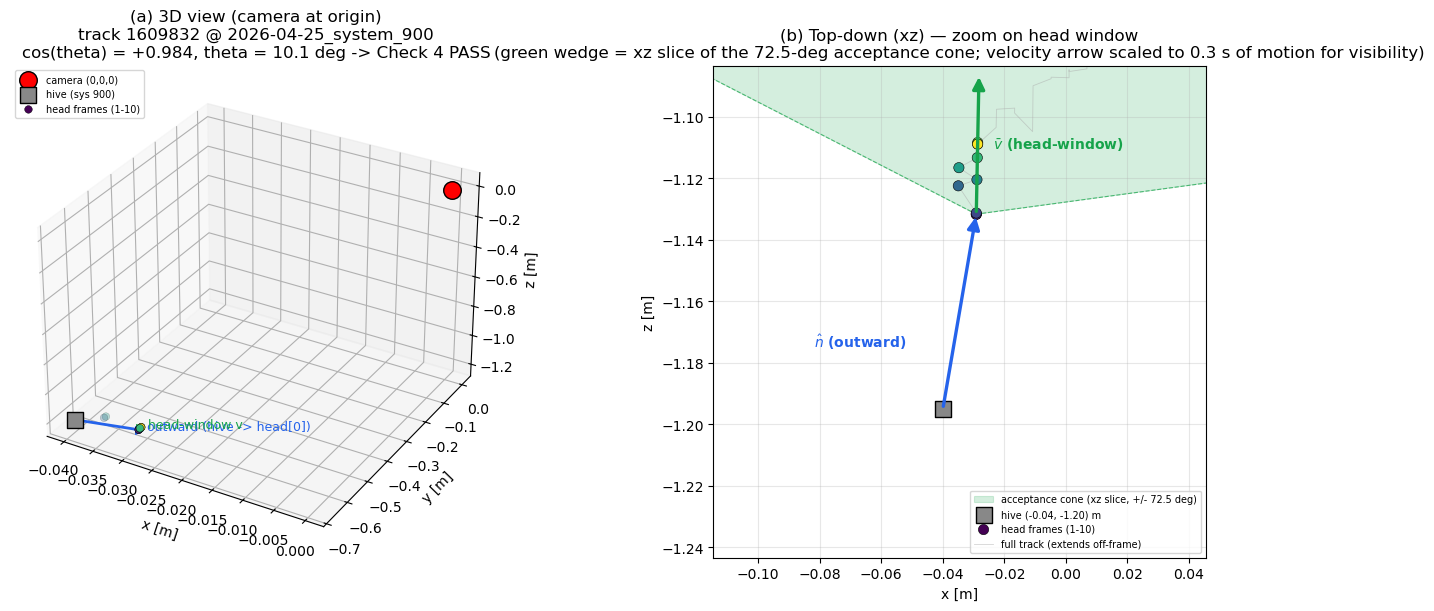

In [51]:
# ── Figure: 3D view + ZOOMED top-down (xz) view with acceptance cone ──
from matplotlib.patches import Wedge

# threshold geometry derived from APPROACH_COS_MIN_EXIT
ANG_HALF_DEG = float(np.degrees(np.arccos(APPROACH_COS_MIN_EXIT)))

fig = plt.figure(figsize=(13.5, 6.2))

# ---- Left: full 3D view (camera at origin, full head window) ----------------
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(0, 0, 0, c="red", s=160, marker="o", edgecolor="black", linewidth=1,
           label="camera (0,0,0)")
ax.scatter(*hive, c="#888", s=120, marker="s", edgecolor="black", linewidth=1,
           label=f"hive (sys {TARGET_SYS})")
ax.scatter(head[:, 0], head[:, 1], head[:, 2],
           c=np.arange(len(head)), cmap="viridis", s=30,
           edgecolor="black", linewidth=0.3, label="head frames (1-10)")

def _arrow3d(ax, base, vec, color, label=None, scale=1.0):
    tip = base + scale * vec
    ax.plot([base[0], tip[0]], [base[1], tip[1]], [base[2], tip[2]],
            color=color, lw=2.0)
    ax.scatter(*tip, color=color, s=30, marker=">")
    if label: ax.text(*tip, "  " + label, color=color, fontsize=9)
_arrow3d(ax, hive,    outward,        "#2563EB",
         "outward (hive -> head[0])", scale=1.0)
_arrow3d(ax, head[0], mean_v * 0.1,   "#16A34A",
         "head-window v",             scale=1.0)

ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title(f"(a) 3D view (camera at origin)\n"
             f"track {TARGET_UID} @ {TARGET_DAY}\n"
             f"cos(theta) = {cos_outward:+.3f}, theta = {angle_deg:.1f} deg "
             f"-> Check 4 {'PASS' if check4_pass else 'REJECT'}")
ax.legend(fontsize=7, loc="upper left")

# ---- Right: ZOOMED top-down (xz) panel with the acceptance cone -------------
ax = fig.add_subplot(1, 2, 2)
ax.set_aspect("equal")

# zoom around the midpoint of hive and head[0] in the xz plane
mid_x = (hive[0] + head[0, 0]) / 2
mid_z = (hive[2] + head[0, 2]) / 2
PAD = 0.08                                      # ~16 cm box
ax.set_xlim(mid_x - PAD, mid_x + PAD)
ax.set_ylim(mid_z - PAD, mid_z + PAD)

# acceptance cone projected onto the xz plane (around the xz component of n_hat)
n_xz       = np.array([outward[0], outward[2]])
n_xz       = n_xz / np.linalg.norm(n_xz)
theta_n_xz = float(np.degrees(np.arctan2(n_xz[1], n_xz[0])))
wedge_r    = 0.10
ax.add_patch(Wedge((head[0, 0], head[0, 2]), wedge_r,
                   theta1=theta_n_xz - ANG_HALF_DEG,
                   theta2=theta_n_xz + ANG_HALF_DEG,
                   facecolor="#16A34A", alpha=0.18, edgecolor="#16A34A", lw=0.8,
                   label=f"acceptance cone (xz slice, +/- {ANG_HALF_DEG:.1f} deg)"))
for sign in (-1, +1):
    th = np.radians(theta_n_xz + sign * ANG_HALF_DEG)
    ax.plot([head[0, 0], head[0, 0] + wedge_r * np.cos(th)],
            [head[0, 2], head[0, 2] + wedge_r * np.sin(th)],
            color="#16A34A", lw=0.8, linestyle="--", alpha=0.7)

# hive, head frames, full track (extends off-frame)
ax.scatter(hive[0], hive[2], c="#888", s=140, marker="s",
           edgecolor="black", linewidth=1, zorder=5,
           label=f"hive ({hive[0]:.2f}, {hive[2]:.2f}) m")
ax.scatter(head[:, 0], head[:, 2], c=np.arange(len(head)),
           cmap="viridis", s=55, edgecolor="black", linewidth=0.4,
           label="head frames (1-10)", zorder=4)
ax.plot(coords[:, 0], coords[:, 2], "-", color="#aaa", lw=0.6, alpha=0.5,
        label="full track (extends off-frame)", zorder=2)

# outward arrow (hive -> head[0])
ax.annotate("", xy=(head[0, 0], head[0, 2]), xytext=(hive[0], hive[2]),
            arrowprops=dict(arrowstyle="-|>", color="#2563EB", lw=2.4,
                            mutation_scale=18), zorder=6)
ax.text(hive[0] - 0.012, hive[2] + 0.020, r"$\hat n$ (outward)",
        color="#2563EB", fontsize=10, ha="right", fontweight="bold", zorder=7)

# head-window mean velocity, scaled to 0.3 s of motion for visibility in the zoom
V_SCALE = 0.30
v_end = head[0] + mean_v * V_SCALE
ax.annotate("", xy=(v_end[0], v_end[2]), xytext=(head[0, 0], head[0, 2]),
            arrowprops=dict(arrowstyle="-|>", color="#16A34A", lw=2.4,
                            mutation_scale=18), zorder=6)
# Calculate the midpoint of the green arrow in the xz plane
v_mid_x = (head[0, 0] + v_end[0]) / 2
v_mid_z = (head[0, 2] + v_end[2]) / 2

# Place text at the midpoint, offset slightly to the right so it doesn't overlap the line
ax.text(v_mid_x + 0.005, v_mid_z, r"$\bar v$ (head-window)",
        color="#16A34A", fontsize=10, fontweight="bold", zorder=7, va="center")

ax.set_xlabel("x [m]"); ax.set_ylabel("z [m]")
ax.set_title(f"(b) Top-down (xz) — zoom on head window\n"
             f"(green wedge = xz slice of the {ANG_HALF_DEG:.1f}-deg acceptance cone; "
             f"velocity arrow scaled to {V_SCALE:.1f} s of motion for visibility)")
ax.legend(fontsize=7, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()

# Save into Overleaf/Images so main4.tex can pick it up directly.
FIG_OUT = Path("../../../../Overleaf/Images/flowervisit_allignment.png")
FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_OUT, dpi=150, bbox_inches="tight")
print(f"saved {FIG_OUT.resolve()}")
plt.show()


**Reading the figure.**

- **Red dot at the origin** is the camera. The world coordinate system
  has its origin there; the camera is the absolute reference for all
  positions in `flight_tracks.csv`.
- **Grey square** is the hive entrance, at its per-system world
  coordinate. For system 900 this is about $1.2$~m in front of the
  camera and $0.67$~m below.
- **Coloured dots** are the first 10 frames of the chosen track,
  coloured by frame index. The bee is leaving the hive area and
  moving into the canopy.
- **Blue arrow** is the *outward direction* $\hat n$ — from the hive
  centre to the bee's first observed position. This vector is local
  to the hive; the camera position does not appear in its definition.
- **Green arrow** is the *head-window mean velocity* $\bar v$, drawn
  from `head[0]` for $0.1$ seconds (for visibility — the vector is
  ten times shorter than what the bee actually moves in one second).
- **Yellow box** shows the cosine, the angle, and the verdict.

A pass means the green arrow falls inside the $\pm 72.5^\circ$ cone
around the blue arrow. The example above passes with
$\theta \approx 10^\circ$ — well inside the cone. To see what a
borderline track looks like, change `TARGET_UID` to a candidate that
the v3 classifier flagged as marginal and re-run.